Old version

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import yfinance as yf
import requests
from pandas_datareader import data as pdr


START = "1995-01-01"
END   = "2025-12-01"
MARKET = "SPY"
CONTEXT_LENGTH = 256

FRED_SERIES = {
    "DFF": "fed_funds",
    "DGS10": "rate_10y",
    "DGS2": "rate_2y",
    "T10Y2Y": "yc_slope_10y2y",
    "CPIAUCSL": "cpi",
    "UNRATE": "unemp",
    "INDPRO": "indpro",
    "VIXCLS": "vix",
    "DBAA": "dbaa",
    "DAAA": "daaa",
}

SPLITS = {
    "gfc_2008_2010": ("2008-01-01", "2010-12-31"),
    "covid_2020_2021": ("2020-01-01", "2021-12-31"),
    "inflation_2022_2023": ("2022-01-01", "2023-12-31"),
}

OUT_ROOT = "dataset_finance_no_fred"


def ensure_dirs():
    os.makedirs(os.path.join(OUT_ROOT, "eval_csv"), exist_ok=True)
    os.makedirs(os.path.join(OUT_ROOT, "eval_csv_with_context"), exist_ok=True)
    os.makedirs(os.path.join(OUT_ROOT, "eval_jsonl"), exist_ok=True)
    os.makedirs(os.path.join(OUT_ROOT, "eval_jsonl_with_context"), exist_ok=True)
    os.makedirs(os.path.join(OUT_ROOT, "metadata"), exist_ok=True)


def get_sp500_tickers() -> list[str]:
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/91.0.4472.124 Safari/537.36"
        )
    }
    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status()
    tickers = pd.read_html(response.text)[0]["Symbol"].astype(str).tolist()
    return [t.replace(".", "-") for t in tickers]


def download_close(tickers: list[str], start: str, end: str) -> pd.DataFrame:
    px = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        auto_adjust=False,
        progress=False,
        group_by="ticker",
        threads=True,
    )

    price_field = "Close"

    if isinstance(px.columns, pd.MultiIndex):
        close = pd.concat(
            {t: px[t][price_field] for t in tickers if t in px.columns.get_level_values(0)},
            axis=1,
        )
    else:
        close = px[price_field].to_frame(tickers[0])

    return close.sort_index()


def log_returns(close_df: pd.DataFrame) -> pd.DataFrame:
    return np.log(close_df).diff()


def download_fred(series_map: dict, start: str, end: str) -> pd.DataFrame:
    macro = pdr.DataReader(list(series_map.keys()), "fred", start, end)
    return macro.rename(columns=series_map).sort_index()


def transform_macro(macro: pd.DataFrame) -> pd.DataFrame:
    macro = macro.copy()

    if "cpi" in macro.columns:
        macro["cpi"] = macro["cpi"].pct_change(12)

    if "indpro" in macro.columns:
        macro["indpro"] = macro["indpro"].pct_change(12)

    if "dbaa" in macro.columns and "daaa" in macro.columns:
        macro["baa_aaa_spread"] = macro["dbaa"] - macro["daaa"]

    macro = macro.drop(columns=[c for c in ["dbaa", "daaa"] if c in macro.columns], errors="ignore")
    return macro


def build_full_panel():
    tickers = get_sp500_tickers()
    all_tickers = sorted(set(tickers + [MARKET]))

    close = download_close(all_tickers, START, END)
    rets = log_returns(close)

    market_ret = rets[MARKET].rename("market_ret_1d")
    firm_rets = rets.drop(columns=[MARKET], errors="ignore")

    macro = download_fred(FRED_SERIES, START, END)
    macro = transform_macro(macro)

    idx = rets.index
    macro = macro.reindex(idx).ffill().shift(1)

    panel = firm_rets.copy()
    panel["market_ret_1d"] = market_ret
    for c in macro.columns:
        panel[c] = macro[c]

    panel = panel.sort_index()

    return tickers, firm_rets, market_ret, macro, panel


def get_split_with_context_index(index: pd.DatetimeIndex, split_start: str, split_end: str, context_length: int):
    split_start = pd.to_datetime(split_start)
    split_end = pd.to_datetime(split_end)

    idx = pd.Index(index)
    eval_mask = (idx >= split_start) & (idx <= split_end)
    eval_positions = np.where(eval_mask)[0]

    if len(eval_positions) == 0:
        return None, None, None

    first_eval_pos = int(eval_positions[0])
    last_eval_pos = int(eval_positions[-1])

    start_pos_with_context = max(0, first_eval_pos - context_length)

    used_index = idx[start_pos_with_context:last_eval_pos + 1]
    eval_start_in_used = first_eval_pos - start_pos_with_context

    return used_index, eval_start_in_used, len(eval_positions)


def write_eval_csvs(panel: pd.DataFrame):
    for split_name, (a, b) in SPLITS.items():
        used_index, eval_start_in_used, eval_len = get_split_with_context_index(
            panel.index, a, b, CONTEXT_LENGTH
        )
        if used_index is None:
            print(f"[{split_name}] skipped: no rows in split")
            continue

        # plain eval csv
        plain_df = panel.loc[a:b].copy()
        plain_df = plain_df.reset_index().rename(columns={"index": "date"})
        plain_df["is_eval_target"] = 1
        plain_df.to_csv(
            os.path.join(OUT_ROOT, "eval_csv", f"{split_name}.csv"),
            index=False,
        )

        # with context csv
        ctx_df = panel.loc[used_index].copy()
        ctx_df = ctx_df.reset_index().rename(columns={"index": "date"})
        ctx_df["is_eval_target"] = 0
        ctx_df.loc[eval_start_in_used:, "is_eval_target"] = 1
        ctx_df.to_csv(
            os.path.join(OUT_ROOT, "eval_csv_with_context", f"{split_name}_with_context.csv"),
            index=False,
        )

        print(
            f"[{split_name}] csv rows: plain={len(plain_df)}, "
            f"with_context={len(ctx_df)}, context_rows={eval_start_in_used}, eval_rows={eval_len}"
        )


def write_eval_jsonl_for_split(
    split_name: str,
    split_range: tuple[str, str],
    firm_rets: pd.DataFrame,
    market_ret: pd.Series,
    macro: pd.DataFrame,
    out_path_plain: str,
    out_path_ctx: str,
    min_len: int = 32,
):
    split_start, split_end = split_range

    used_index, eval_start_in_used, eval_len = get_split_with_context_index(
        firm_rets.index, split_start, split_end, CONTEXT_LENGTH
    )
    if used_index is None:
        print(f"[{split_name}] skipped jsonl: no rows in split")
        return

    n_plain = 0
    n_ctx = 0

    with open(out_path_plain, "w", encoding="utf-8") as f_plain, \
         open(out_path_ctx, "w", encoding="utf-8") as f_ctx:

        for t in firm_rets.columns:
            df = pd.DataFrame(index=firm_rets.index)
            df["sequence"] = firm_rets[t]
            df["market_ret_1d"] = market_ret
            for c in macro.columns:
                df[c] = macro[c]

            # plain eval segment
            df_plain = df.loc[split_start:split_end].dropna().copy()

            if len(df_plain) >= min_len:
                obj_plain = {
                    "ticker": t,
                    "segment_id": 0,
                    "dates": [d.strftime("%Y-%m-%d") for d in df_plain.index],
                    "sequence": df_plain["sequence"].astype(float).tolist(),
                    "main_features": df_plain[["sequence", "market_ret_1d"]].astype(float).values.tolist(),
                    "macro_features": df_plain[list(macro.columns)].astype(float).values.tolist(),
                    "eval_start_date": df_plain.index[0].strftime("%Y-%m-%d"),
                    "eval_length": len(df_plain),
                    "context_length": 0,
                }
                f_plain.write(json.dumps(obj_plain) + "\n")
                n_plain += 1

            # eval with context
            df_ctx = df.loc[used_index].copy().dropna().copy()

            # after dropna the split position may shift, so recompute inside df_ctx
            eval_mask_ctx = (df_ctx.index >= pd.to_datetime(split_start)) & (df_ctx.index <= pd.to_datetime(split_end))
            if eval_mask_ctx.sum() < min_len:
                continue

            first_eval_date = df_ctx.index[eval_mask_ctx][0]
            context_len_effective = int((df_ctx.index < first_eval_date).sum())

            obj_ctx = {
                "ticker": t,
                "segment_id": 0,
                "dates": [d.strftime("%Y-%m-%d") for d in df_ctx.index],
                "sequence": df_ctx["sequence"].astype(float).tolist(),
                "main_features": df_ctx[["sequence", "market_ret_1d"]].astype(float).values.tolist(),
                "macro_features": df_ctx[list(macro.columns)].astype(float).values.tolist(),
                "eval_start_date": first_eval_date.strftime("%Y-%m-%d"),
                "eval_length": int(eval_mask_ctx.sum()),
                "context_length": context_len_effective,
            }
            f_ctx.write(json.dumps(obj_ctx) + "\n")
            n_ctx += 1

    print(
        f"[{split_name}] wrote plain jsonl: {n_plain} rows -> {out_path_plain}"
    )
    print(
        f"[{split_name}] wrote with_context jsonl: {n_ctx} rows -> {out_path_ctx}"
    )


def save_metadata(panel: pd.DataFrame, macro: pd.DataFrame):
    debug_df = pd.DataFrame(index=panel.index)
    debug_df["market_ret_1d"] = panel["market_ret_1d"]
    for c in macro.columns:
        debug_df[c] = panel[c]
    debug_df.to_csv(os.path.join(OUT_ROOT, "metadata", "aligned_market_macro_debug.csv"))

    pd.Series(list(macro.columns), name="macro_feature").to_csv(
        os.path.join(OUT_ROOT, "metadata", "macro_feature_order.csv"),
        index=False
    )

    with open(os.path.join(OUT_ROOT, "metadata", "build_config.json"), "w") as f:
        json.dump(
            {
                "start": START,
                "end": END,
                "market": MARKET,
                "context_length": CONTEXT_LENGTH,
                "fred_series": FRED_SERIES,
                "splits": SPLITS,
            },
            f,
            indent=2,
        )


def main():
    ensure_dirs()

    tickers, firm_rets, market_ret, macro, panel = build_full_panel()
    save_metadata(panel, macro)
    write_eval_csvs(panel)

    for split_name, split_range in SPLITS.items():
        out_path_plain = os.path.join(OUT_ROOT, "eval_jsonl", f"{split_name}.jsonl")
        out_path_ctx = os.path.join(OUT_ROOT, "eval_jsonl_with_context", f"{split_name}_with_context.jsonl")

        write_eval_jsonl_for_split(
            split_name=split_name,
            split_range=split_range,
            firm_rets=firm_rets,
            market_ret=market_ret,
            macro=macro,
            out_path_plain=out_path_plain,
            out_path_ctx=out_path_ctx,
            min_len=32,
        )

    print("Done.")
    print(f"Plain eval JSONLs: {os.path.join(OUT_ROOT, 'eval_jsonl')}")
    print(f"With-context JSONLs: {os.path.join(OUT_ROOT, 'eval_jsonl_with_context')}")
    print(f"Plain eval CSVs: {os.path.join(OUT_ROOT, 'eval_csv')}")
    print(f"With-context CSVs: {os.path.join(OUT_ROOT, 'eval_csv_with_context')}")


if __name__ == "__main__":
    main()

/tmp/ipykernel_231581/3616129158.py:56: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tickers = pd.read_html(response.text)[0]["Symbol"].astype(str).tolist()

1 Failed download:
['ELV']: TypeError("'NoneType' object is not subscriptable")


ValueError: No objects to concatenate

In [ ]:
import json

with open("dataset_finance_fred2/eval_jsonl_with_context/gfc_2008_2010_with_context.jsonl", "r") as f:
    row = json.loads(next(f))

print(row.keys())
print("first date:", row["dates"][0])
print("eval start date:", row["eval_start_date"])
print("context_length:", row["context_length"])
print("eval_length:", row["eval_length"])
print("total_length:", len(row["dates"]))

dict_keys(['ticker', 'segment_id', 'dates', 'sequence', 'main_features', 'macro_features', 'eval_start_date', 'eval_length', 'context_length'])
first date: 2006-12-22
eval start date: 2008-01-02
context_length: 256
eval_length: 757
total_length: 1013


New version

In [1]:
import os
import json
import numpy as np
import pandas as pd
import yfinance as yf
import requests
from pandas_datareader import data as pdr


START = "1995-01-01"
END = "2025-12-01"
MARKET = "SPY"

OUT_ROOT = "dataset_finance_fred_features"

FRED_SERIES = {
    "DFF": "fed_funds",
    "DGS10": "rate_10y",
    "DGS2": "rate_2y",
    "T10Y2Y": "yc_slope_10y2y",
    "VIXCLS": "vix",
    "DBAA": "dbaa",
    "DAAA": "daaa",
}

SPLITS = {
    "gfc_2008_2010": ("2008-01-01", "2010-12-31"),
    "covid_2020_2021": ("2020-01-01", "2021-12-31"),
    "inflation_2022_2023": ("2022-01-01", "2023-12-31"),
}

MAIN_FEATURE_ORDER = [
    "sequence",
    "market_ret_1d",
    "log_volume",
    "volume_z_20d",
    "rv_20d",
    "rv_60d",
    "mom_20d",
    "mom_60d",
    "drawdown_60d",
    "dollar_volume_log",
    "beta_252d",
]


def ensure_dirs():
    for subdir in ["metadata", "finetune", "eval", "eval_jsonl"]:
        os.makedirs(os.path.join(OUT_ROOT, subdir), exist_ok=True)


def get_sp500_tickers() -> list[str]:
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/91.0.4472.124 Safari/537.36"
        )
    }
    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status()
    tickers = pd.read_html(response.text)[0]["Symbol"].astype(str).tolist()
    return [t.replace(".", "-") for t in tickers]


def download_yahoo_fields(tickers: list[str,], start: str, end: str) -> dict[str, pd.DataFrame]:
    raw = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        auto_adjust=False,
        progress=False,
        group_by="ticker",
        threads=True,
    )

    fields = ["Adj Close", "Close", "Volume"]
    out = {}

    if isinstance(raw.columns, pd.MultiIndex):
        available_tickers = raw.columns.get_level_values(0).unique()

        for field in fields:
            out[field] = pd.concat(
                {
                    t: raw[t][field]
                    for t in tickers
                    if t in available_tickers and field in raw[t].columns
                },
                axis=1,
            ).sort_index()
    else:
        for field in fields:
            out[field] = raw[field].to_frame(tickers[0]).sort_index()

    return out


def log_returns(price_df: pd.DataFrame) -> pd.DataFrame:
    return np.log(price_df).diff()


def download_fred(series_map: dict, start: str, end: str) -> pd.DataFrame:
    macro = pdr.DataReader(list(series_map.keys()), "fred", start, end)
    return macro.rename(columns=series_map).sort_index()


def transform_macro(macro: pd.DataFrame) -> pd.DataFrame:
    macro = macro.copy()

    if "dbaa" in macro.columns and "daaa" in macro.columns:
        macro["baa_aaa_spread"] = macro["dbaa"] - macro["daaa"]

    macro = macro.drop(columns=["dbaa", "daaa"], errors="ignore")
    return macro


def build_firm_features(
    adj_close: pd.DataFrame,
    close: pd.DataFrame,
    volume: pd.DataFrame,
    market_ret: pd.Series,
) -> dict[str, pd.DataFrame]:
    firm_ret = log_returns(adj_close)

    log_volume = np.log1p(volume)

    volume_mean_20 = log_volume.rolling(20, min_periods=10).mean()
    volume_std_20 = log_volume.rolling(20, min_periods=10).std()
    volume_z_20d = (log_volume - volume_mean_20) / volume_std_20

    rv_20d = firm_ret.rolling(20, min_periods=10).std()
    rv_60d = firm_ret.rolling(60, min_periods=30).std()

    mom_20d = firm_ret.rolling(20, min_periods=10).sum()
    mom_60d = firm_ret.rolling(60, min_periods=30).sum()

    rolling_max_60 = adj_close.rolling(60, min_periods=30).max()
    drawdown_60d = adj_close / rolling_max_60 - 1.0

    dollar_volume_log = np.log1p(close * volume)

    market_var_252 = market_ret.rolling(252, min_periods=126).var()
    beta_252d = pd.DataFrame(index=firm_ret.index, columns=firm_ret.columns, dtype=float)

    for ticker in firm_ret.columns:
        cov_252 = firm_ret[ticker].rolling(252, min_periods=126).cov(market_ret)
        beta_252d[ticker] = cov_252 / market_var_252

    return {
        "sequence": firm_ret,
        "log_volume": log_volume,
        "volume_z_20d": volume_z_20d,
        "rv_20d": rv_20d,
        "rv_60d": rv_60d,
        "mom_20d": mom_20d,
        "mom_60d": mom_60d,
        "drawdown_60d": drawdown_60d,
        "dollar_volume_log": dollar_volume_log,
        "beta_252d": beta_252d,
    }


def save_metadata(tickers: list[str]):
    pd.Series(tickers, name="ticker").to_csv(
        os.path.join(OUT_ROOT, "metadata", "tickers.csv"),
        index=False,
    )

    pd.DataFrame(
        {"fred_code": list(FRED_SERIES.keys()), "name": list(FRED_SERIES.values())}
    ).to_csv(
        os.path.join(OUT_ROOT, "metadata", "fred_series.csv"),
        index=False,
    )

    pd.Series(MAIN_FEATURE_ORDER, name="main_feature").to_csv(
        os.path.join(OUT_ROOT, "metadata", "main_feature_order.csv"),
        index=False,
    )

    with open(os.path.join(OUT_ROOT, "metadata", "build_config.json"), "w") as f:
        json.dump(
            {
                "start": START,
                "end": END,
                "market": MARKET,
                "fred_series": FRED_SERIES,
                "splits": SPLITS,
                "main_feature_order": MAIN_FEATURE_ORDER,
            },
            f,
            indent=2,
        )


def _build_exclusion_mask(index: pd.DatetimeIndex, splits: dict) -> pd.Series:
    keep = pd.Series(True, index=index)
    for _, (a, b) in splits.items():
        keep.loc[a:b] = False
    return keep


def write_train_jsonl_contiguous_covariates(
    firm_features: dict[str, pd.DataFrame],
    market_ret: pd.Series,
    macro: pd.DataFrame,
    splits: dict,
    out_path: str,
    min_len: int = 512,
    max_gap_days: int = 7,
):
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)

    base_index = firm_features["sequence"].index
    keep_mask = _build_exclusion_mask(base_index, splits)

    n_seq = 0
    n_tickers = 0

    with open(out_path, "w", encoding="utf-8") as f:
        for ticker in firm_features["sequence"].columns:
            df = pd.DataFrame(index=base_index)

            for feature_name, feature_df in firm_features.items():
                df[feature_name] = feature_df[ticker]

            df["market_ret_1d"] = market_ret

            for c in macro.columns:
                df[c] = macro[c]

            df = df[keep_mask]
            df = df.replace([np.inf, -np.inf], np.nan).dropna()

            if len(df) == 0:
                continue

            dt = df.index.to_series().diff().dt.days.fillna(1)
            breaks = (dt > max_gap_days).cumsum()

            seg_id = 0
            wrote_any = False

            for _, seg in df.groupby(breaks):
                if len(seg) < min_len:
                    continue

                obj = {
                    "ticker": ticker,
                    "segment_id": seg_id,
                    "sequence": seg["sequence"].astype(float).tolist(),
                    "main_features": seg[MAIN_FEATURE_ORDER].astype(float).values.tolist(),
                    "macro_features": seg[list(macro.columns)].astype(float).values.tolist(),
                }

                f.write(json.dumps(obj) + "\n")

                seg_id += 1
                n_seq += 1
                wrote_any = True

            if wrote_any:
                n_tickers += 1

    total_dates = len(base_index)
    train_dates = int(keep_mask.sum())
    eval_dates = total_dates - train_dates

    print(f"[split] total dates={total_dates} | train dates={train_dates} | eval-excluded dates={eval_dates}")
    print(f"[train.jsonl] wrote {n_seq} sequences from {n_tickers} tickers to {out_path}")


def write_eval_csvs(
    firm_features: dict[str, pd.DataFrame],
    market_ret: pd.Series,
    macro: pd.DataFrame,
    splits: dict,
):
    eval_dir = os.path.join(OUT_ROOT, "eval")
    os.makedirs(eval_dir, exist_ok=True)

    base_index = firm_features["sequence"].index
    firm_rets = firm_features["sequence"]

    panel_wide = firm_rets.copy()
    panel_wide["market_ret_1d"] = market_ret

    for feature_name, feature_df in firm_features.items():
        if feature_name == "sequence":
            continue

        for ticker in feature_df.columns:
            panel_wide[f"{ticker}__{feature_name}"] = feature_df[ticker]

    for c in macro.columns:
        panel_wide[c] = macro[c]

    panel_wide = panel_wide.replace([np.inf, -np.inf], np.nan)

    for name, (a, b) in splits.items():
        df = panel_wide.loc[a:b].copy()
        df.reset_index().rename(columns={"index": "date"}).to_csv(
            os.path.join(eval_dir, f"{name}.csv"),
            index=False,
        )


def write_eval_jsonl_for_split(
    split_name: str,
    split_range: tuple[str, str],
    firm_features: dict[str, pd.DataFrame],
    market_ret: pd.Series,
    macro: pd.DataFrame,
    out_path: str,
    min_len: int = 32,
):
    a, b = split_range

    n_seq = 0
    n_tickers = 0

    base_index = firm_features["sequence"].index

    with open(out_path, "w", encoding="utf-8") as f:
        for ticker in firm_features["sequence"].columns:
            df = pd.DataFrame(index=base_index)

            for feature_name, feature_df in firm_features.items():
                df[feature_name] = feature_df[ticker]

            df["market_ret_1d"] = market_ret

            for c in macro.columns:
                df[c] = macro[c]

            df = df.loc[a:b]
            df = df.replace([np.inf, -np.inf], np.nan).dropna()

            if len(df) < min_len:
                continue

            obj = {
                "ticker": ticker,
                "segment_id": 0,
                "dates": [d.strftime("%Y-%m-%d") for d in df.index],
                "sequence": df["sequence"].astype(float).tolist(),
                "main_features": df[MAIN_FEATURE_ORDER].astype(float).values.tolist(),
                "macro_features": df[list(macro.columns)].astype(float).values.tolist(),
            }

            f.write(json.dumps(obj) + "\n")

            n_seq += 1
            n_tickers += 1

    print(f"[{split_name}] wrote {n_seq} eval sequences from {n_tickers} tickers -> {out_path}")


def save_debug_files(
    firm_features: dict[str, pd.DataFrame],
    market_ret: pd.Series,
    macro: pd.DataFrame,
):
    metadata_dir = os.path.join(OUT_ROOT, "metadata")

    pd.Series(list(macro.columns), name="macro_feature").to_csv(
        os.path.join(metadata_dir, "macro_feature_order.csv"),
        index=False,
    )

    debug_df = pd.DataFrame(index=market_ret.index)
    debug_df["market_ret_1d"] = market_ret

    for c in macro.columns:
        debug_df[c] = macro[c]

    debug_df.to_csv(os.path.join(metadata_dir, "aligned_market_macro_debug.csv"))

    missing_report = {}
    for name, df in firm_features.items():
        missing_report[name] = float(df.isna().mean().mean())

    pd.Series(missing_report, name="avg_missing_share").to_csv(
        os.path.join(metadata_dir, "firm_feature_missing_report.csv")
    )


def main():
    ensure_dirs()

    print("Downloading S&P 500 tickers...")
    tickers = get_sp500_tickers()
    all_tickers = sorted(set(tickers + [MARKET]))
    save_metadata(tickers)

    print(f"Downloading Yahoo Finance data for {len(all_tickers)} tickers...")
    fields = download_yahoo_fields(all_tickers, START, END)

    adj_close = fields["Adj Close"]
    close = fields["Close"]
    volume = fields["Volume"]

    rets = log_returns(adj_close)
    market_ret = rets[MARKET].rename("market_ret_1d")

    firm_adj_close = adj_close.drop(columns=[MARKET], errors="ignore")
    firm_close = close.drop(columns=[MARKET], errors="ignore")
    firm_volume = volume.drop(columns=[MARKET], errors="ignore")

    print("Building firm-level Yahoo features...")
    firm_features = build_firm_features(
        adj_close=firm_adj_close,
        close=firm_close,
        volume=firm_volume,
        market_ret=market_ret,
    )

    print("Downloading FRED macro data...")
    macro = download_fred(FRED_SERIES, START, END)
    macro = transform_macro(macro)

    idx = rets.index
    macro = macro.reindex(idx).ffill().shift(1)

    save_debug_files(
        firm_features=firm_features,
        market_ret=market_ret,
        macro=macro,
    )

    out_train = os.path.join(OUT_ROOT, "finetune", "train.jsonl")

    print("Writing train JSONL...")
    write_train_jsonl_contiguous_covariates(
        firm_features=firm_features,
        market_ret=market_ret,
        macro=macro,
        splits=SPLITS,
        out_path=out_train,
        min_len=512,
        max_gap_days=7,
    )

    print("Writing eval CSVs...")
    write_eval_csvs(
        firm_features=firm_features,
        market_ret=market_ret,
        macro=macro,
        splits=SPLITS,
    )

    print("Writing eval JSONLs...")
    for split_name, split_range in SPLITS.items():
        out_path = os.path.join(OUT_ROOT, "eval_jsonl", f"{split_name}.jsonl")

        write_eval_jsonl_for_split(
            split_name=split_name,
            split_range=split_range,
            firm_features=firm_features,
            market_ret=market_ret,
            macro=macro,
            out_path=out_path,
            min_len=32,
        )

    print("Done.")
    print(f"Train JSONL: {out_train}")
    print(f"Eval CSVs:   {os.path.join(OUT_ROOT, 'eval')}")
    print(f"Eval JSONL:  {os.path.join(OUT_ROOT, 'eval_jsonl')}")
    print(f"Metadata:    {os.path.join(OUT_ROOT, 'metadata')}")


if __name__ == "__main__":
    main()

/tmp/ipykernel_227175/693171440.py:63: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tickers = pd.read_html(response.text)[0]["Symbol"].astype(str).tolist()



2 Failed downloads:
['AMAT', 'BKR']: TypeError("'NoneType' object is not subscriptable")


Building firm-level Yahoo features...
Writing train JSONL...
[split] total dates=7780 | train dates=6017 | eval-excluded dates=1763
[train.jsonl] wrote 861 sequences from 474 tickers to dataset_finance_fred_features/finetune/train.jsonl
Writing eval CSVs...


/tmp/ipykernel_227175/693171440.py:295: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  panel_wide[f"{ticker}__{feature_name}"] = feature_df[ticker]
/tmp/ipykernel_227175/693171440.py:295: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  panel_wide[f"{ticker}__{feature_name}"] = feature_df[ticker]
/tmp/ipykernel_227175/693171440.py:295: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(

Writing eval JSONLs...
[gfc_2008_2010] wrote 424 eval sequences from 424 tickers -> dataset_finance_fred_features/eval_jsonl/gfc_2008_2010.jsonl
[covid_2020_2021] wrote 492 eval sequences from 492 tickers -> dataset_finance_fred_features/eval_jsonl/covid_2020_2021.jsonl
[inflation_2022_2023] wrote 496 eval sequences from 496 tickers -> dataset_finance_fred_features/eval_jsonl/inflation_2022_2023.jsonl
Done.
Train JSONL: dataset_finance_fred_features/finetune/train.jsonl
Eval CSVs:   dataset_finance_fred_features/eval
Eval JSONL:  dataset_finance_fred_features/eval_jsonl
Metadata:    dataset_finance_fred_features/metadata


In [ ]:
import json

with open('dataset_finance_fred2/eval_jsonl_with_context/gfc_2008_2010_with_context.jsonl', 'r') as json_file:
    json_list = list(json_file)

itr = 0
for json_str in json_list:
    result = json.loads(json_str)
    print(len(result['sequence']))
    print(f"result: {result}")
    print(isinstance(result, dict))
    itr += 1
    if itr == 1:
        break



1013
result: {'ticker': 'A', 'segment_id': 0, 'dates': ['2006-12-22', '2006-12-26', '2006-12-27', '2006-12-28', '2006-12-29', '2007-01-03', '2007-01-04', '2007-01-05', '2007-01-08', '2007-01-09', '2007-01-10', '2007-01-11', '2007-01-12', '2007-01-16', '2007-01-17', '2007-01-18', '2007-01-19', '2007-01-22', '2007-01-23', '2007-01-24', '2007-01-25', '2007-01-26', '2007-01-29', '2007-01-30', '2007-01-31', '2007-02-01', '2007-02-02', '2007-02-05', '2007-02-06', '2007-02-07', '2007-02-08', '2007-02-09', '2007-02-12', '2007-02-13', '2007-02-14', '2007-02-15', '2007-02-16', '2007-02-20', '2007-02-21', '2007-02-22', '2007-02-23', '2007-02-26', '2007-02-27', '2007-02-28', '2007-03-01', '2007-03-02', '2007-03-05', '2007-03-06', '2007-03-07', '2007-03-08', '2007-03-09', '2007-03-12', '2007-03-13', '2007-03-14', '2007-03-15', '2007-03-16', '2007-03-19', '2007-03-20', '2007-03-21', '2007-03-22', '2007-03-23', '2007-03-26', '2007-03-27', '2007-03-28', '2007-03-29', '2007-03-30', '2007-04-02', '2007-

In [13]:
import numpy as np

data = np.load("results/mamba_fred2/gfc_p64.npz", allow_pickle=True)
for k in data.files:
    print(k, np.array(data[k]).shape)

predictions (4422, 64)
labels (4422, 64)
dates (283008,)
tickers (4422,)
forecast_origin_dates (4422,)
window_start_dates (4422,)
eval_start_dates (4422,)


In [8]:
import json

with open("dataset_finance_fred2/finetune/train.jsonl", "r") as f:
    row = json.loads(next(f))

print(row.keys())
print(row)

dict_keys(['ticker', 'segment_id', 'sequence', 'main_features', 'macro_features'])
{'ticker': 'A', 'segment_id': 0, 'sequence': [-0.08597881710264366, 0.08597881710264366, -0.09531019798482543, 0.02621588281794862, 0.0030394902007797597, 0.02250657756243868, 0.0014825673941847306, 0.017621577613332384, 0.027280959696684537, 0.008462662545673183, 0.02770266312495817, -0.010989145404237455, -0.0013822174994304604, 0.01373648101594327, -0.02346551330270996, 0.016620858973139363, -0.05651215370384932, -0.030998780396466863, 0.1252512881293022, -0.028170809246738315, 0.020202707317519497, -0.00534767495432753, 0.019907759010640014, 0.04496583094076945, 0.059737505829736026, 0.15228923500924774, 0.15762896407567428, 0.09594125472091353, -0.024751791545442714, -0.07118946317547081, -0.07946418861838067, -0.064037429910766, -0.038820012333513176, 0.0800427145106477, 0.058813047276095265, -0.013692592690840222, -0.020427807976085344, 0.01489788693505778, 0.011029508149390299, 0.0446901903213752

### Добавляю из обучающей выборки для eval части контекст, коорый модель смотрит, а не предсказывает его 

In [ ]:
# For jsonl eval files
import os
import json
import pandas as pd
from typing import Dict, List, Any


CONTEXT_LENGTH = 256

TRAIN_JSONL = "dataset_finance_fred2/finetune/train.jsonl"
EVAL_JSONL_DIR = "dataset_finance_fred2/eval_jsonl"
OUT_DIR = "dataset_finance_fred2/eval_jsonl_with_context"

SPLITS = {
    "gfc_2008_2010": ("2008-01-01", "2010-12-31"),
    "covid_2020_2021": ("2020-01-01", "2021-12-31"),
    "inflation_2022_2023": ("2022-01-01", "2023-12-31"),
}


def ensure_dirs():
    os.makedirs(OUT_DIR, exist_ok=True)


def read_jsonl(path: str) -> List[Dict[str, Any]]:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows


def index_train_segments_by_ticker(train_rows: List[Dict[str, Any]]) -> Dict[str, List[Dict[str, Any]]]:
    by_ticker = {}
    for row in train_rows:
        ticker = row["ticker"]
        if ticker not in by_ticker:
            by_ticker[ticker] = []
        by_ticker[ticker].append(row)

    # sort each ticker's segments by last date if available
    for ticker, segs in by_ticker.items():
        def seg_last_date(seg):
            if "dates" in seg and len(seg["dates"]) > 0:
                return pd.to_datetime(seg["dates"][-1])
            return pd.Timestamp.min

        segs.sort(key=seg_last_date)
    return by_ticker


def find_context_segment(train_segments_for_ticker: List[Dict[str, Any]], split_start: str):
    split_start = pd.to_datetime(split_start)

    candidates = []
    for seg in train_segments_for_ticker:
        if "dates" not in seg or len(seg["dates"]) == 0:
            continue
        last_date = pd.to_datetime(seg["dates"][-1])
        if last_date < split_start:
            candidates.append(seg)

    if not candidates:
        return None

    # take the segment whose end is closest before split start
    candidates.sort(key=lambda seg: pd.to_datetime(seg["dates"][-1]))
    return candidates[-1]


def tail_slice_segment(seg: Dict[str, Any], context_length: int):
    n = len(seg["dates"])
    start_idx = max(0, n - context_length)

    out = {
        "dates": seg["dates"][start_idx:],
        "sequence": seg["sequence"][start_idx:] if "sequence" in seg else None,
        "main_features": seg["main_features"][start_idx:] if "main_features" in seg else None,
        "macro_features": seg["macro_features"][start_idx:] if "macro_features" in seg else None,
    }
    return out


def merge_context_and_eval(context_part: Dict[str, Any], eval_row: Dict[str, Any]):
    merged = {
        "ticker": eval_row["ticker"],
        "segment_id": eval_row.get("segment_id", 0),
        "eval_start_date": eval_row["dates"][0],
        "eval_length": len(eval_row["dates"]),
    }

    context_dates = context_part["dates"] if context_part is not None else []
    eval_dates = eval_row["dates"]

    merged["dates"] = context_dates + eval_dates

    if "sequence" in eval_row:
        context_seq = context_part["sequence"] if context_part is not None and context_part["sequence"] is not None else []
        merged["sequence"] = context_seq + eval_row["sequence"]

    if "main_features" in eval_row:
        context_main = context_part["main_features"] if context_part is not None and context_part["main_features"] is not None else []
        merged["main_features"] = context_main + eval_row["main_features"]

    if "macro_features" in eval_row:
        context_macro = context_part["macro_features"] if context_part is not None and context_part["macro_features"] is not None else []
        merged["macro_features"] = context_macro + eval_row["macro_features"]

    return merged


def build_eval_with_context_for_split(split_name: str, split_start: str):
    eval_path = os.path.join(EVAL_JSONL_DIR, f"{split_name}.jsonl")
    out_path = os.path.join(OUT_DIR, f"{split_name}.jsonl")

    train_rows = read_jsonl(TRAIN_JSONL)
    eval_rows = read_jsonl(eval_path)

    train_by_ticker = index_train_segments_by_ticker(train_rows)

    n_written = 0
    n_missing_context = 0

    with open(out_path, "w", encoding="utf-8") as f:
        for eval_row in eval_rows:
            ticker = eval_row["ticker"]
            train_segments = train_by_ticker.get(ticker, [])

            context_seg = find_context_segment(train_segments, split_start)
            if context_seg is None:
                context_part = None
                n_missing_context += 1
            else:
                context_part = tail_slice_segment(context_seg, CONTEXT_LENGTH)

            merged = merge_context_and_eval(context_part, eval_row)
            f.write(json.dumps(merged) + "\n")
            n_written += 1

    print(f"[{split_name}] wrote {n_written} rows -> {out_path}")
    print(f"[{split_name}] missing context for {n_missing_context} tickers")


def main():
    ensure_dirs()
    for split_name, (split_start, _) in SPLITS.items():
        build_eval_with_context_for_split(split_name, split_start)
    print("Done.")


if __name__ == "__main__":
    main()

In [ ]:
#For csv eval files
import os
import pandas as pd


CONTEXT_LENGTH = 256

EVAL_CSV_DIR = "dataset_finance_fred2/eval"
OUT_CSV_DIR = "dataset_finance_fred2/eval_with_context_csv"

SPLITS = {
    "gfc_2008_2010": ("2008-01-01", "2010-12-31"),
    "covid_2020_2021": ("2020-01-01", "2021-12-31"),
    "inflation_2022_2023": ("2022-01-01", "2023-12-31"),
}


def ensure_dirs():
    os.makedirs(OUT_CSV_DIR, exist_ok=True)


def extend_eval_csv_with_context(full_csv_path: str, split_name: str, split_start: str, split_end: str):
    df = pd.read_csv(full_csv_path)

    date_col = None
    for c in df.columns:
        if c.lower() in {"date", "datetime", "timestamp"}:
            date_col = c
            break
    if date_col is None:
        raise ValueError(f"No date column in {full_csv_path}")

    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)

    split_start = pd.to_datetime(split_start)
    split_end = pd.to_datetime(split_end)

    in_split = (df[date_col] >= split_start) & (df[date_col] <= split_end)
    split_idx = df.index[in_split]

    if len(split_idx) == 0:
        raise ValueError(f"No rows for split {split_name}")

    first_idx = split_idx.min()
    start_idx = max(0, first_idx - CONTEXT_LENGTH)

    out_df = df.iloc[start_idx:split_idx.max() + 1].copy()
    out_df["is_eval_target"] = (out_df[date_col] >= split_start).astype(int)

    out_path = os.path.join(OUT_CSV_DIR, f"{split_name}.csv")
    out_df.to_csv(out_path, index=False)

    print(f"[{split_name}] wrote extended csv -> {out_path}")
    print(
        f"rows={len(out_df)}, context_rows={(out_df['is_eval_target'] == 0).sum()}, "
        f"eval_rows={(out_df['is_eval_target'] == 1).sum()}"
    )


def main():
    ensure_dirs()

    for split_name, (split_start, split_end) in SPLITS.items():
        # here I assume you already have a full csv for the whole period
        full_csv_path = os.path.join(EVAL_CSV_DIR, f"{split_name}.csv")
        extend_eval_csv_with_context(full_csv_path, split_name, split_start, split_end)

    print("Done.")


if __name__ == "__main__":
    main()

In [2]:
from compare.baselines import run_panel_baseline 

df_rf, metrics_rf = run_panel_baseline(
    csv_path="dataset_finance_fred2/eval_csv_with_context/gfc_2008_2010_with_context.csv",
    model_name="rf",
    context_length=256,
    horizon=64,
    step=64,
    include_market=True,
    include_macro=True,
    aggregate_mode="none",
    rf_n_estimators=100,
    rf_max_depth=8,
    rf_min_samples_leaf=5,
    rf_n_jobs=1,      # важно
    n_jobs_outer=8,   # параллель по origins
    save_path="results/baselines/rf/gfc_h64s64.csv",
)
print(metrics_rf)

Baseline rf:   0%|          | 0/11 [00:01<?, ?it/s]

KeyboardInterrupt: 

In [16]:
from compare.compute_metrics import compute_metrics_from_dataframe
from compare.download_predictions import load_predictions
import pandas as pd

crisis = 'gfc'
dl_type = 'p64'
baseline_type = 'h64s64'
paths = {
    'fred_full': f'mamba_fred2/{crisis}_{dl_type}.npz', 
    'garch': f'garch/{crisis}_{baseline_type}.csv',
    'ols': f'baselines/ols/{crisis}_{baseline_type}.csv', 
    'ridge': f'baselines/ridge/{crisis}_{baseline_type}.csv', 
    'pls': f'baselines/pls/{crisis}_{baseline_type}.csv',
    'pcr': f'baselines/pcr/{crisis}_{baseline_type}.csv',
    'rf': f'baselines/rf/{crisis}_{baseline_type}.csv', 
}
results = dict()
for key, path in paths.items():
    full_path = f'results/{path}'
    df = load_predictions(full_path, duplicate_mode='last')
    metrics = compute_metrics_from_dataframe(df)
    results[key] = metrics

df_results = pd.DataFrame.from_dict(results, orient='index')
df_results

,n,mse,rmse,mae,huber,sign_accuracy,negative_day_sign_accuracy,mase,tail_rmse_10,tail_mae_10,downside_hit_rate_10,downside_precision_10,downside_f1_10,tail_rmse_5,tail_mae_5,downside_hit_rate_5,downside_precision_5,downside_f1_5
fred_full,283008,0.001143,0.033813,0.021454,0.000572,0.501318,0.363874,0.921044,0.071491,0.060835,0.119006,0.119006,0.119006,0.092732,0.081668,0.054127,0.054123,0.054125
garch,291200,0.001152,0.033946,0.021512,0.000576,0.496576,0.328748,0.917178,0.071425,0.060766,0.169677,0.169532,0.169604,0.092674,0.081629,0.112157,0.111788,0.111972
ols,265472,0.002434,0.049332,0.033621,0.001217,0.494817,0.504910,1.431368,0.080676,0.064089,0.140990,0.140990,0.140990,0.101067,0.084016,0.074205,0.074205,0.074205
ridge,265472,0.002414,0.049127,0.033494,0.001207,0.494772,0.505026,1.425939,0.080553,0.064008,0.141442,0.141442,0.141442,0.100982,0.083962,0.074657,0.074657,0.074657
pls,265472,0.001249,0.035337,0.022587,0.000624,0.499736,0.439955,0.961588,0.070381,0.058005,0.189280,0.189280,0.189280,0.091531,0.079004,0.140500,0.140500,0.140500
pcr,265472,0.001226,0.035020,0.022364,0.000613,0.501902,0.464021,0.952094,0.070064,0.058334,0.173158,0.173158,0.173158,0.091243,0.079391,0.116619,0.116619,0.116619
rf,265472,0.001299,0.036046,0.023366,0.000650,0.519079,0.376701,0.994768,0.071978,0.059429,0.149201,0.148882,0.149041,0.093425,0.080815,0.089348,0.087560,0.088445


In [17]:
print(df_results.to_latex())

\begin{tabular}{lrrrrrrrrrrrrrrrrrr}
\toprule
 & n & mse & rmse & mae & huber & sign_accuracy & negative_day_sign_accuracy & mase & tail_rmse_10 & tail_mae_10 & downside_hit_rate_10 & downside_precision_10 & downside_f1_10 & tail_rmse_5 & tail_mae_5 & downside_hit_rate_5 & downside_precision_5 & downside_f1_5 \\
\midrule
fred_full & 283008 & 0.001143 & 0.033813 & 0.021454 & 0.000572 & 0.501318 & 0.363874 & 0.921044 & 0.071491 & 0.060835 & 0.119006 & 0.119006 & 0.119006 & 0.092732 & 0.081668 & 0.054127 & 0.054123 & 0.054125 \\
garch & 291200 & 0.001152 & 0.033946 & 0.021512 & 0.000576 & 0.496576 & 0.328748 & 0.917178 & 0.071425 & 0.060766 & 0.169677 & 0.169532 & 0.169604 & 0.092674 & 0.081629 & 0.112157 & 0.111788 & 0.111972 \\
ols & 265472 & 0.002434 & 0.049332 & 0.033621 & 0.001217 & 0.494817 & 0.504910 & 1.431368 & 0.080676 & 0.064089 & 0.140990 & 0.140990 & 0.140990 & 0.101067 & 0.084016 & 0.074205 & 0.074205 & 0.074205 \\
ridge & 265472 & 0.002414 & 0.049127 & 0.033494 & 0.001207 &

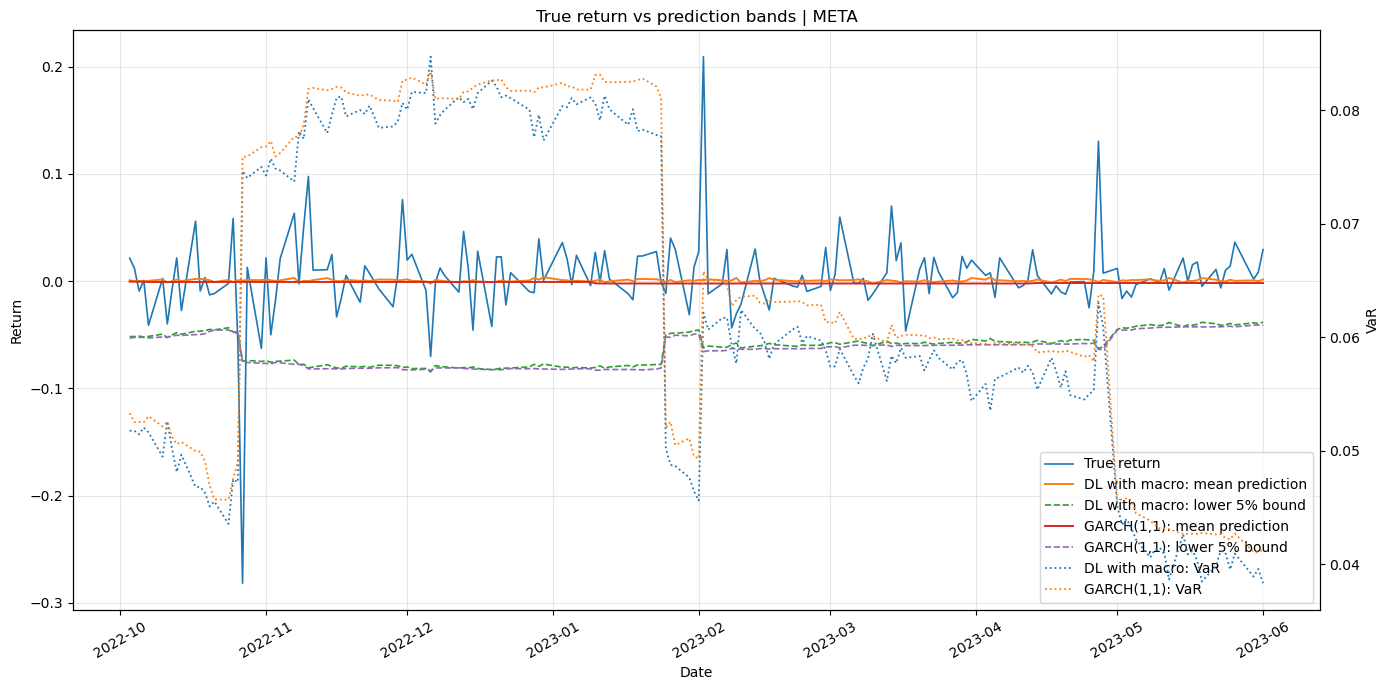

(    ticker       date      true      pred  residual  sigma_hat  pred_mean  \
 188   META 2022-10-03  0.021365  0.000718  0.020647   0.031894   0.000718   
 189   META 2022-10-04  0.011976 -0.000100  0.012076   0.031395  -0.000100   
 190   META 2022-10-05 -0.009310  0.000217 -0.009527   0.031394   0.000217   
 191   META 2022-10-06  0.000647 -0.000390  0.001038   0.031393  -0.000390   
 192   META 2022-10-07 -0.041251  0.000231 -0.041481   0.031512   0.000231   
 ..     ...        ...       ...       ...       ...        ...        ...   
 350   META 2023-05-25  0.013868  0.001138  0.012729   0.024714   0.001138   
 351   META 2023-05-26  0.036334  0.000243  0.036091   0.025022   0.000243   
 352   META 2023-05-30  0.001830  0.000689  0.001141   0.024058   0.000689   
 353   META 2023-05-31  0.008345 -0.000027  0.008372   0.024037  -0.000027   
 354   META 2023-06-01  0.029369  0.001461  0.027908   0.024177   0.001461   
 
      lower_band  var_line  alpha   z_alpha  
 188   -0.051743

In [5]:
from compare.plot_graphics import plot_true_vs_predicted_returns
from compare.download_predictions import load_predictions
from compare.compute_var_and_bands import plot_true_mean_and_band

dl_df = load_predictions('results/mamba_fred2/inf_p64.npz', duplicate_mode='last')
garch_df = load_predictions('results/garch/inf_h64s64.csv', duplicate_mode='last')


plot_true_mean_and_band(
    df_model_1=dl_df,
    df_model_2=garch_df,
    model_1_name="DL with macro",
    model_2_name="GARCH(1,1)",
    ticker="META",
    start_date="2022-10-01",
    end_date="2023-06-01",
    alpha=0.05,
    sigma_window=60,
    show_var_line=True,
)

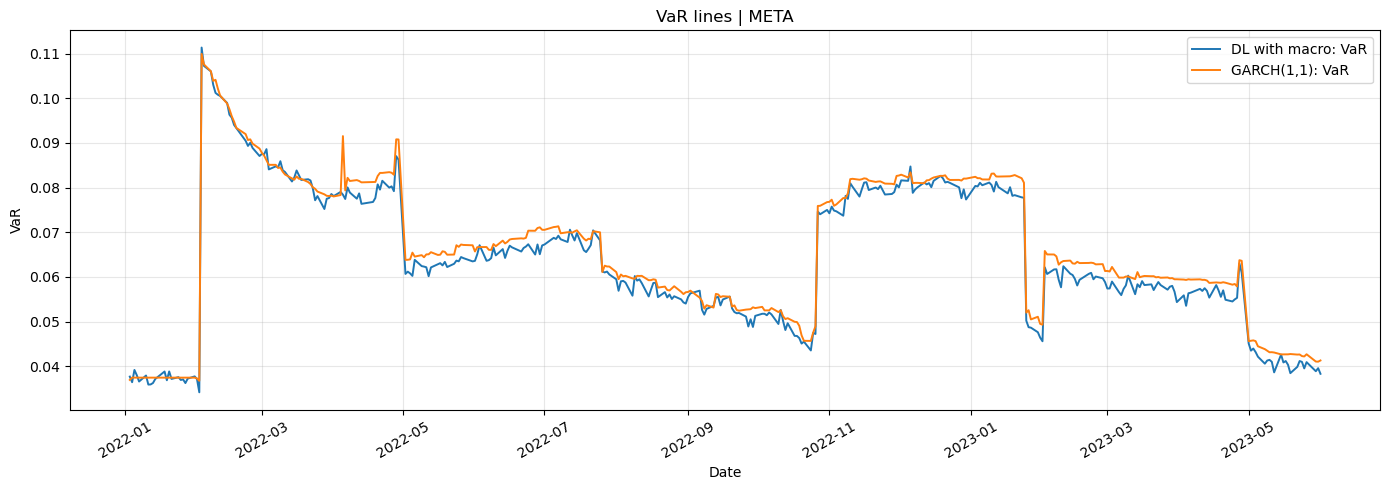

(    ticker       date      true      pred  residual  sigma_hat  pred_mean  \
 0     META 2022-01-03  0.006490  0.000231  0.006259   0.023048   0.000231   
 1     META 2022-01-04 -0.005955  0.001486 -0.007441   0.023048   0.001486   
 2     META 2022-01-05 -0.037419 -0.001257 -0.036162   0.023048  -0.001257   
 3     META 2022-01-06  0.025251 -0.000102  0.025354   0.023048  -0.000102   
 4     META 2022-01-07 -0.002017  0.001331 -0.003348   0.023048   0.001331   
 ..     ...        ...       ...       ...       ...        ...        ...   
 350   META 2023-05-25  0.013868  0.001138  0.012729   0.024714   0.001138   
 351   META 2023-05-26  0.036334  0.000243  0.036091   0.025022   0.000243   
 352   META 2023-05-30  0.001830  0.000689  0.001141   0.024058   0.000689   
 353   META 2023-05-31  0.008345 -0.000027  0.008372   0.024037  -0.000027   
 354   META 2023-06-01  0.029369  0.001461  0.027908   0.024177   0.001461   
 
      lower_band  var_line  alpha   z_alpha  
 0     -0.037680

In [7]:
from compare.compute_var_and_bands import plot_var_only

plot_var_only(
    df_model_1=dl_df,
    df_model_2=garch_df,
    model_1_name="DL with macro",
    model_2_name="GARCH(1,1)",
    ticker="META",
    start_date="2022-01-01",
    end_date="2023-06-01",
)

In [3]:
from compare.quantile_regression_covar import compute_quantile_regression_covar
from compare.download_predictions import load_predictions

dl_df = load_predictions('results/mamba_fred2/inf_p64.npz', duplicate_mode='last')
# garch_df = load_predictions('results/garch/inf_h64s64.csv', duplicate_mode='last')

qr_dl = compute_quantile_regression_covar(
    pred_df=dl_df,
    panel="dataset_finance_fred2/eval_csv_with_context/inflation_2022_2023_with_context.csv",
    ticker="META",
    q=0.05,
    institution_mode="pred",   # важный момент: conditioning on predicted institution signal
    warmup=30,
    step=1,
)

qr_dl_true = compute_quantile_regression_covar(
    pred_df=dl_df,
    panel="dataset_finance_fred2/eval_csv_with_context/inflation_2022_2023_with_context.csv",
    ticker="META",
    q=0.05,
    institution_mode="true",   # важный момент: conditioning on predicted institution signal
    warmup=30,
    step=1,
)

QR-CoVaR META:   0%|          | 0/418 [00:00<?, ?it/s]

/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


QR-CoVaR META:   0%|          | 0/418 [00:00<?, ?it/s]

/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


Saved plot to: plots/meta_qr_var.png


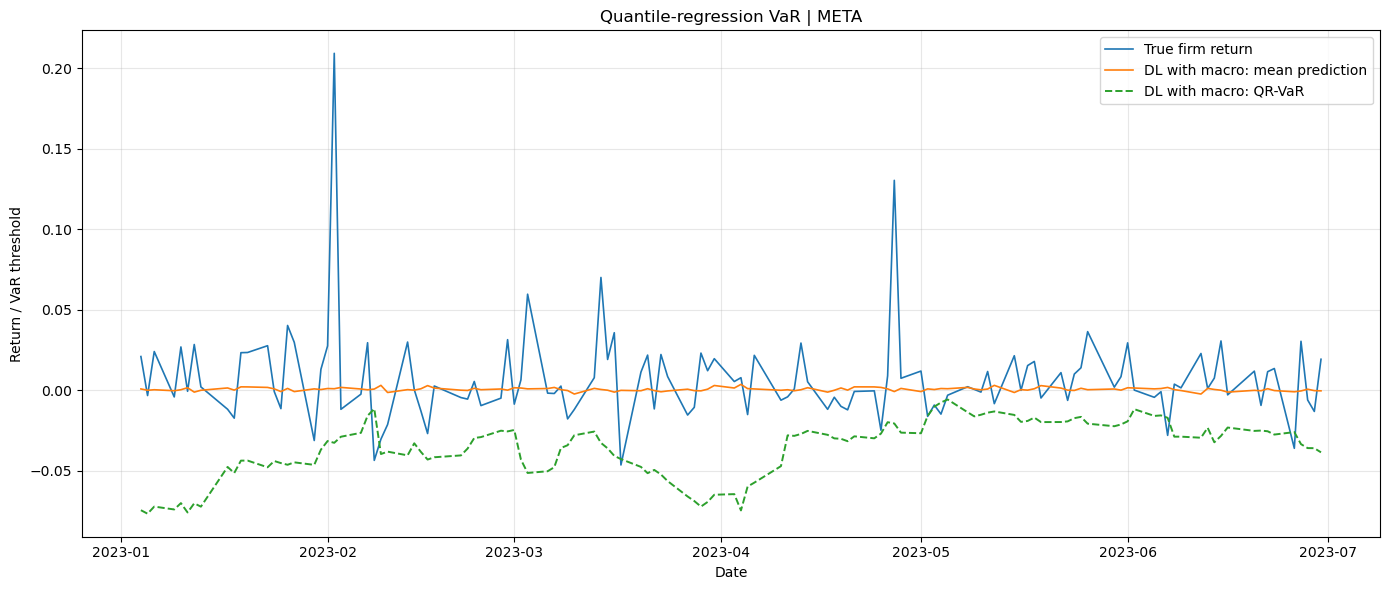

In [2]:
from compare.quantile_regression_covar import plot_qr_var

plot_qr_var(
    qr_df_1=qr_dl,
    # qr_df_2=qr_garch,
    model_1_name="DL with macro",
    # model_2_name="GARCH",
    ticker="META",
    start_date="2023-01-01",
    end_date="2023-06-30",
    save_path="plots/meta_qr_var.png",
)

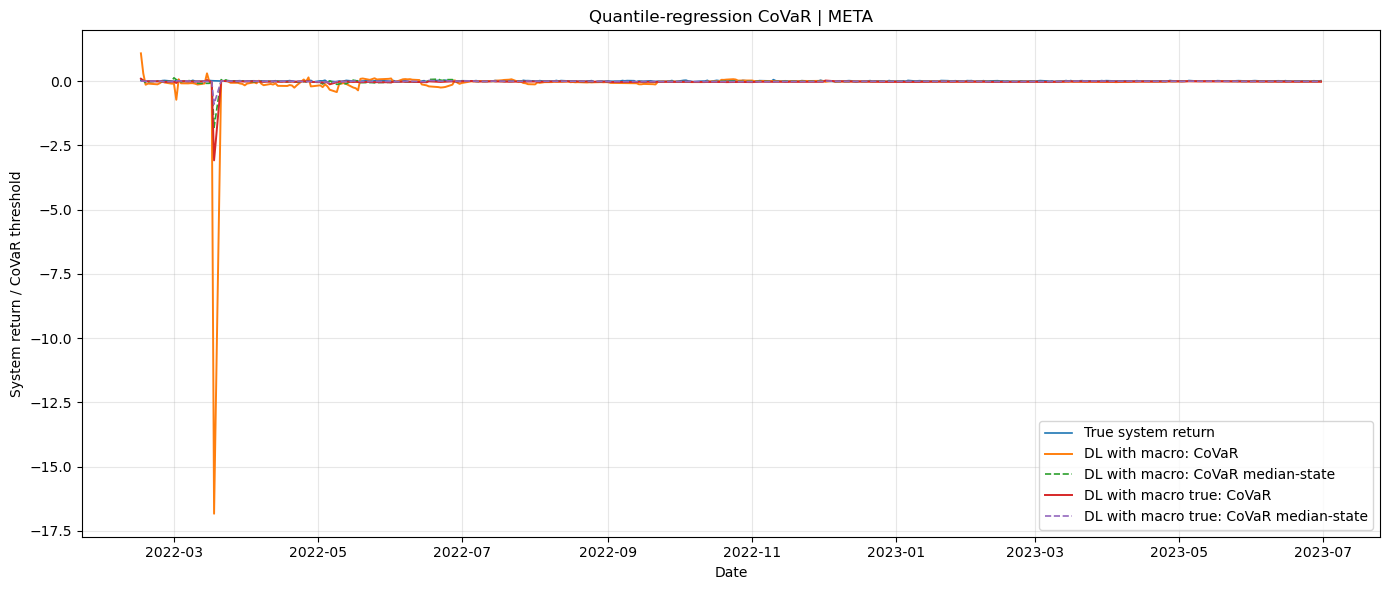

In [4]:
from compare.quantile_regression_covar import plot_qr_covar

plot_qr_covar(
    qr_df_1=qr_dl,
    qr_df_2=qr_dl_true,
    model_1_name="DL with macro",
    model_2_name="DL with macro true",
    ticker="META",
    start_date="2022-01-10",
    end_date="2023-06-30",
    # save_path="plots/meta_qr_covar.png",
)

In [4]:
from compare.quantile_regression_covar import compute_quantile_regression_covar, compute_reference_quantile_regression_covar, evaluate_covar_tracking
from compare.download_predictions import load_predictions

dl_df = load_predictions('results/mamba_fred_full/inf_p64.npz', duplicate_mode='last')
garch_df = load_predictions('results/garch/inf_h64s64.csv', duplicate_mode='last')

qr_dl_pred = compute_quantile_regression_covar(
    pred_df=dl_df,
    panel="dataset_finance_fred_full/eval_csv_with_context/inflation_2022_2023_with_context.csv",
    ticker="META",
    q=0.05,
    institution_mode="pred",
    warmup=252,
    step=1,
)

qr_garch_pred = compute_quantile_regression_covar(
    pred_df=garch_df,
    panel="dataset_finance_fred_full/eval_csv_with_context/inflation_2022_2023_with_context.csv",
    ticker="META",
    q=0.05,
    institution_mode="pred",
    warmup=252,
    step=1,
)

qr_ref = compute_quantile_regression_covar(
    pred_df=dl_df,  # можно и dl_df, и garch_df, главное чтобы были date + true
    panel="dataset_finance_fred_full/eval_csv_with_context/inflation_2022_2023_with_context.csv",
    ticker="META",
    q=0.05,
    institution_mode="true",
    warmup=252,
    step=1,
)

metrics_dl = evaluate_covar_tracking(
    predicted_qr_df=qr_dl_pred,
    reference_qr_df=qr_ref,
    ticker="META",
    start_date="2023-01-01",
    end_date="2023-06-30",
)
print(metrics_dl)

metrics_garch = evaluate_covar_tracking(
    predicted_qr_df=qr_garch_pred,
    reference_qr_df=qr_ref,
    ticker="META",
    start_date="2023-01-01",
    end_date="2023-06-30",
)
print(metrics_garch)

QR-CoVaR META:   0%|          | 0/196 [00:00<?, ?it/s]

/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


QR-CoVaR META:   0%|          | 0/196 [00:00<?, ?it/s]

/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


QR-CoVaR META:   0%|          | 0/196 [00:00<?, ?it/s]

/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


{'n': 123, 'covar_rmse': 0.0069583497637137875, 'covar_corr': 0.6167787233784827, 'delta_covar_rmse': 0.007764813500241836, 'delta_covar_corr': 0.5495401709820966}
{'n': 123, 'covar_rmse': 0.02972532454385974, 'covar_corr': 0.1671902846075952, 'delta_covar_rmse': 0.0317456423530545, 'delta_covar_corr': 0.6981177226929637}


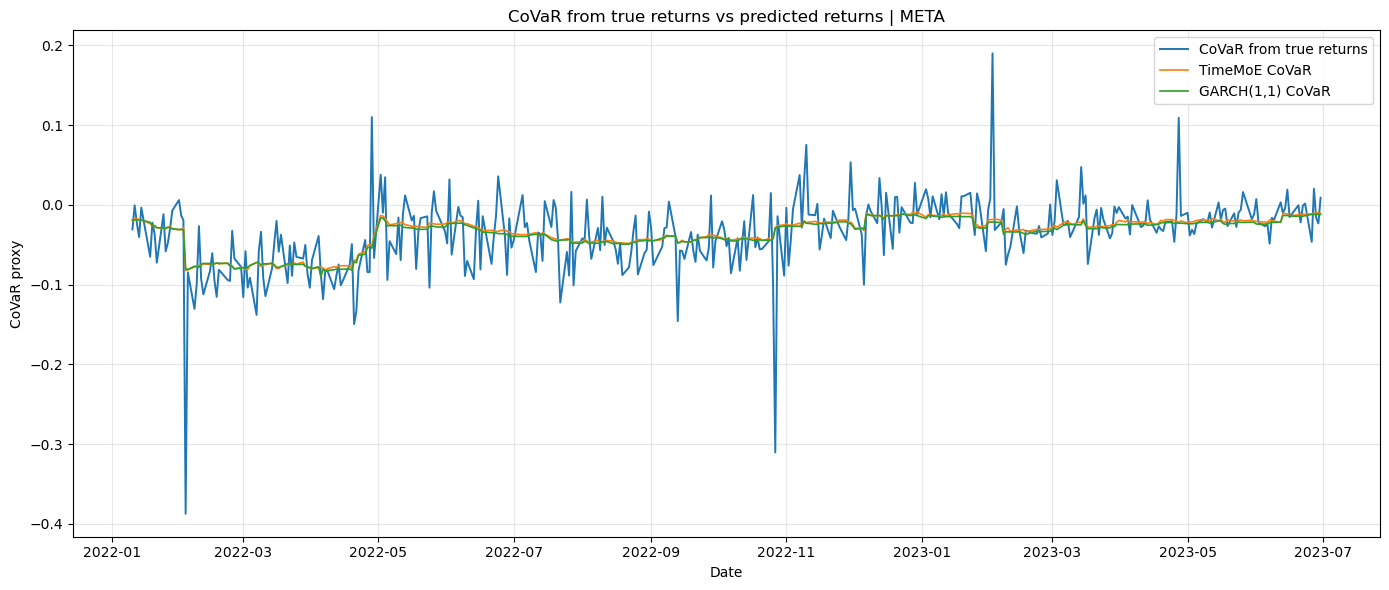

In [4]:
from compare.plot_graphics import plot_covar_true_vs_predicted

plot_covar_true_vs_predicted(
    df_1=dl_df,
    df_2=garch_df,
    panel="dataset_finance_fred2/eval_csv_with_context/inflation_2022_2023_with_context.csv",
    model_1_name="TimeMoE",
    model_2_name="GARCH(1,1)",
    ticker="META",
    start_date="2022-01-10",
    end_date="2023-06-30",
    aggregate_mode="last",
    q=0.05,
    # save_path="plots/meta_delta_covar_compare.png",
)

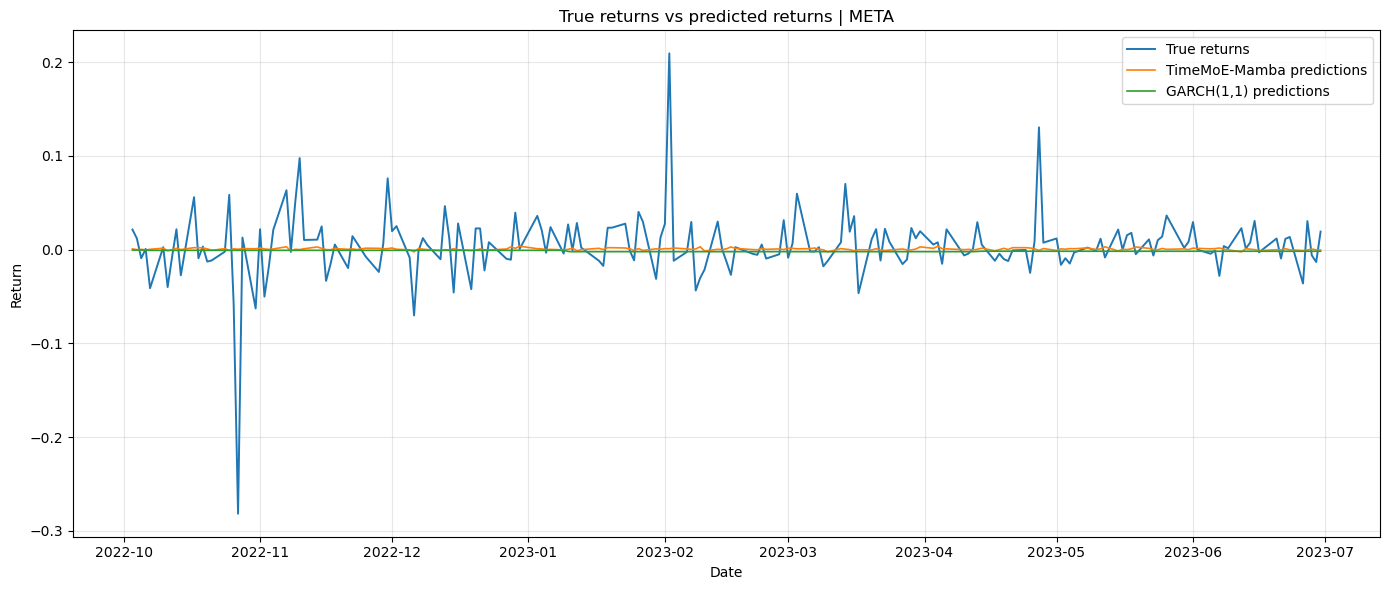

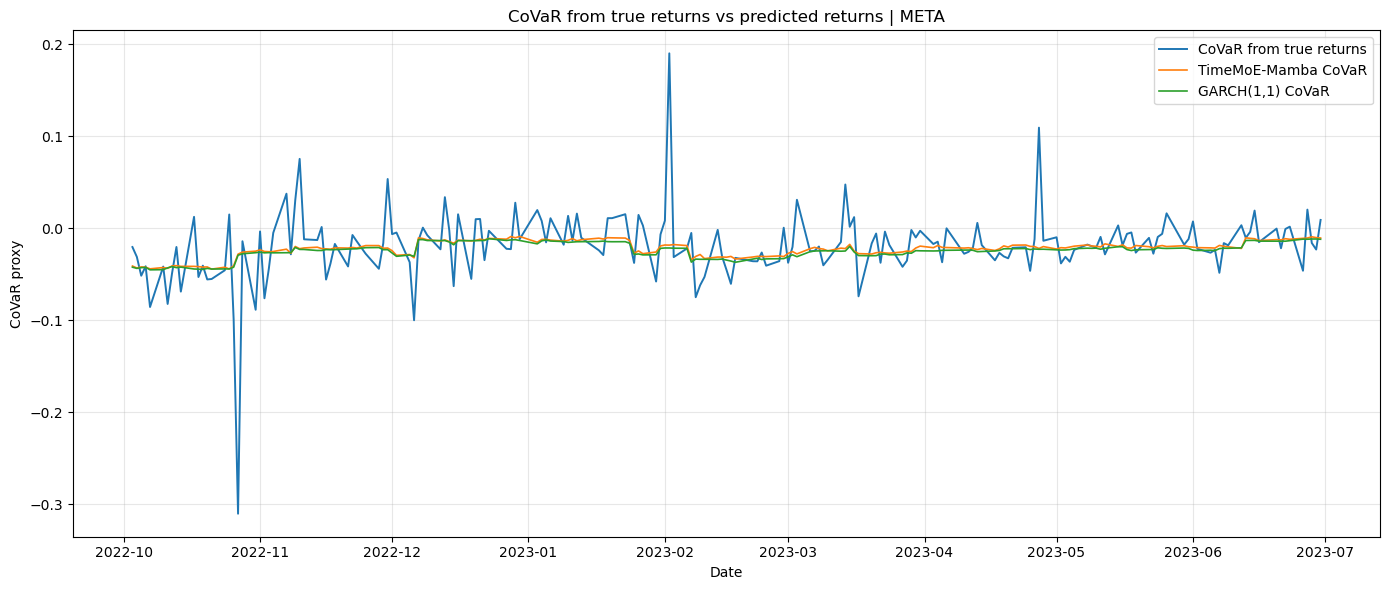

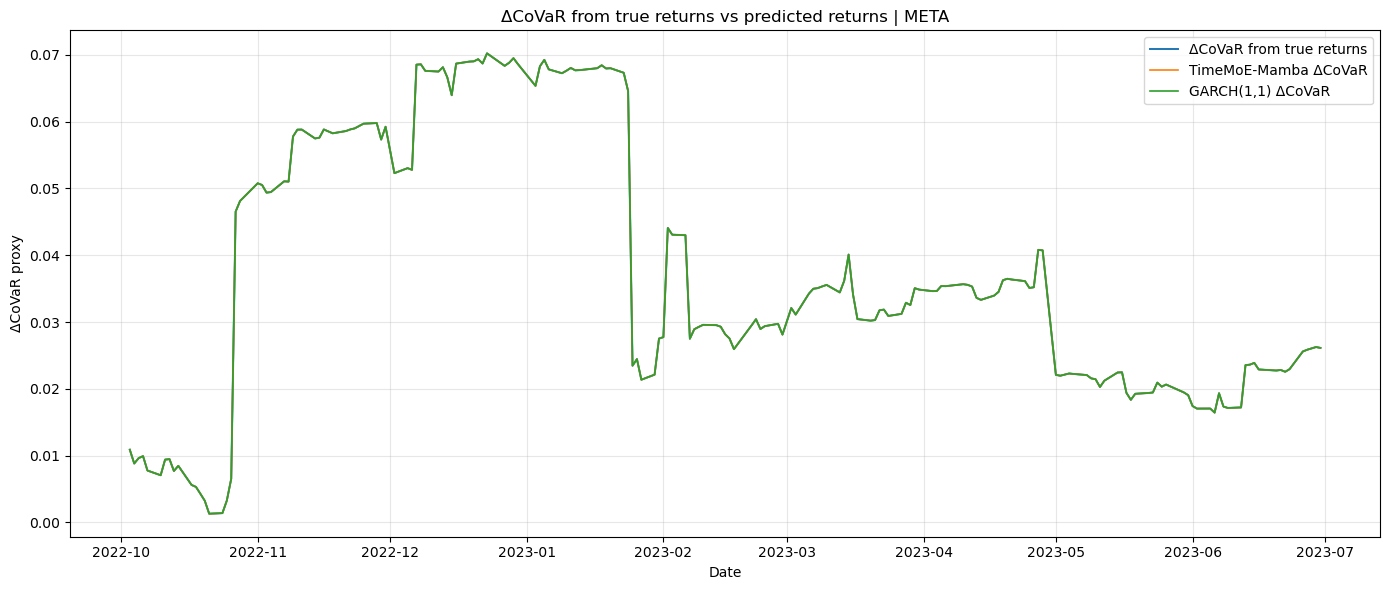

In [2]:
from compare.plot_graphics import plot_requested_graphs

plot_requested_graphs(
    graph_types=["returns", "covar", "delta_covar"],
    df_1=dl_df,
    df_2=garch_df,
    panel="dataset_finance_fred2/eval_csv_with_context/inflation_2022_2023_with_context.csv",
    model_1_name="TimeMoE-Mamba",
    model_2_name="GARCH(1,1)",
    ticker="META",
    start_date="2022-10-01",
    end_date="2023-06-30",
    aggregate_mode="last",
    # save_dir="plots/meta",
    # file_prefix="dl_vs_garch",
)